Iteration    0 | Loss: 28148711615.5157
Iteration  100 | Loss: 5786195356.0556
Iteration  200 | Loss: 2979249896.2539
Iteration  300 | Loss: 2577270401.6874
Iteration  400 | Loss: 2500324287.4087
Iteration  500 | Loss: 2472471586.0086
Iteration  600 | Loss: 2454850832.2688
Iteration  700 | Loss: 2441176267.1334
Iteration  800 | Loss: 2429965314.0188
Iteration  900 | Loss: 2420589477.9908

Final weights (theta):
[207185.7488845  -16853.76182049 -15543.9097713   14626.99375893
   4709.48441899  18824.8273554  -32730.47708912  15650.81331871
  71966.97982587   9545.3706703  -21543.84827114   2708.75764022
   6220.7070725    9846.87107675]

Test MSE : 4974954915.9485
Test R² : 0.6204

sklearn LinearRegression R²: 0.6254

Saved plots to gradient_descent_plots.png


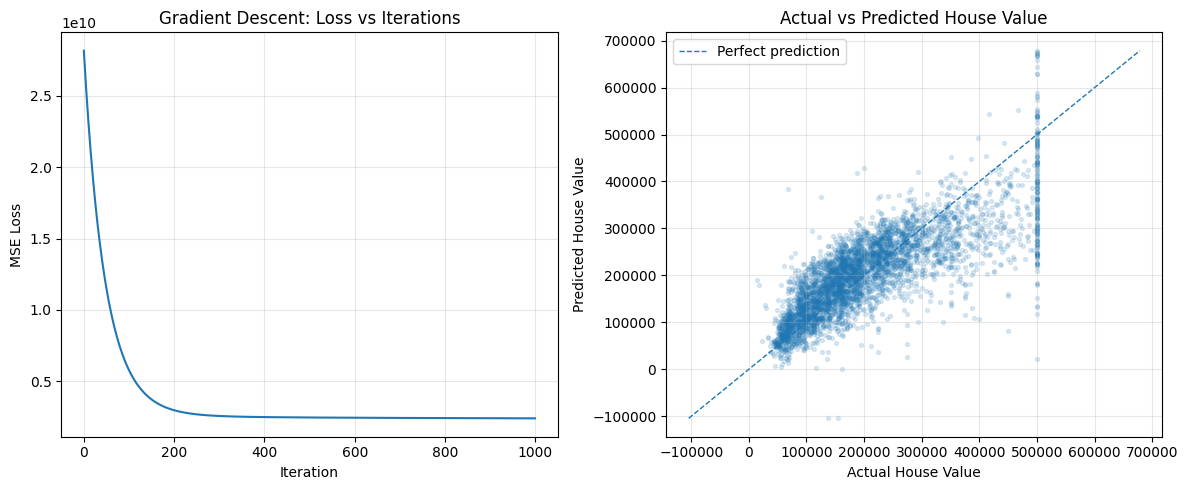

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

df = pd.read_csv("/content/housing.csv")

target_col = "median_house_value"

X = df.drop(columns=[target_col])
y = df[target_col].values.reshape(-1, 1)

X = pd.get_dummies(X, columns=["ocean_proximity"], dtype=float)
X = X.fillna(X.median())

X = X.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    losses = []

    for i in range(n_iters):
        y_pred = X @ theta
        error = y_pred - y

        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)

        gradient = (1 / m) * (X.T @ error)

        theta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss: {loss:.4f}")

    return theta, losses

theta, losses = gradient_descent(
    X_train_b, y_train, lr=0.01, n_iters=1000
)

y_pred = X_test_b @ theta

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal weights (theta):")
print(theta.ravel())

print(f"\nTest MSE : {mse:.4f}")
print(f"Test R² : {r2:.4f}")

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

sk_pred = sk_model.predict(X_test)

print(
    f"\nsklearn LinearRegression R²: "
    f"{r2_score(y_test, sk_pred):.4f}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(range(len(losses)), losses)
axes[0].set_title("Gradient Descent: Loss vs Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, y_pred, alpha=0.15, s=8)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[1].plot(
    lims,
    lims,
    linestyle="--",
    linewidth=1,
    label="Perfect prediction"
)

axes[1].set_title("Actual vs Predicted House Value")
axes[1].set_xlabel("Actual House Value")
axes[1].set_ylabel("Predicted House Value")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gradient_descent_plots.png", dpi=150)

print("\nSaved plots to gradient_descent_plots.png")

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
